# 🎭 Multimodal Sentiment Analysis — MVSA-Single Dataset
**Architecture:** BERT (text) + ResNet-50 (image) → Fusion → 3-class classifier (Positive / Neutral / Negative)

**Pipeline:**
1. Extract & preprocess MVSA-Single zip
2. Build Dataset & DataLoaders
3. Define Multimodal Model
4. Train with early stopping + LR scheduling
5. Evaluate (Accuracy, F1, Confusion Matrix)
6. Save best model for deployment

## 1. Install Dependencies

In [1]:
!pip install transformers torch torchvision scikit-learn matplotlib seaborn Pillow tqdm -q

## 2. Imports & Configuration

In [1]:
import os
import re
import zipfile
import random
import json
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from transformers import BertTokenizer, BertModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# ─── Reproducibility ───────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ─── Config ────────────────────────────────────────────────────────────────
CONFIG = {
    # ── Paths (update ZIP_PATH to your actual file location) ──
    "ZIP_PATH"       : "MVSA_Single.zip",   # <-- change if needed
    "EXTRACT_DIR"    : "./mvsa_single",
    "OUTPUT_DIR"     : "./outputs",

    # ── Model ──
    "BERT_MODEL"     : "bert-base-uncased",
    "MAX_TEXT_LEN"   : 128,
    "IMAGE_SIZE"     : 224,
    "HIDDEN_DIM"     : 512,
    "DROPOUT"        : 0.3,
    "NUM_CLASSES"    : 3,         # negative=0, neutral=1, positive=2

    # ── Training ──
    "BATCH_SIZE"     : 16,
    "NUM_EPOCHS"     : 20,
    "LR"             : 2e-5,
    "WEIGHT_DECAY"   : 1e-4,
    "PATIENCE"       : 4,         # early stopping
    "GRAD_CLIP"      : 1.0,
    "TEST_SIZE"      : 0.15,
    "VAL_SIZE"       : 0.15,
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)

LABEL_MAP  = {"negative": 0, "neutral": 1, "positive": 2}
LABEL_NAMES = ["Negative", "Neutral", "Positive"]

/home/uditanshu/miniconda3/envs/waste-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


## 3. Extract & Parse MVSA-Single Dataset

In [2]:
# ─── 3.1  Extract zip ─────────────────────────────────────────────────────
zip_path   = Path(CONFIG["ZIP_PATH"])
extract_dir = Path(CONFIG["EXTRACT_DIR"])

if not extract_dir.exists():
    print(f"Extracting {zip_path} …")
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(extract_dir)
    print("Done.")
else:
    print("Already extracted.")

# ─── 3.2  Auto-detect dataset root ────────────────────────────────────────
def find_label_file(root: Path):
    for p in root.rglob("labelResultAll.txt"):
        return p
    for p in root.rglob("*.txt"):
        return p
    raise FileNotFoundError("Cannot find label file inside extracted zip.")

label_file = find_label_file(extract_dir)
data_root  = label_file.parent
print(f"Label file : {label_file}")
print(f"Data root  : {data_root}")

Already extracted.
Label file : mvsa_single/MVSA_Single/labelResultAll.txt
Data root  : mvsa_single/MVSA_Single


In [3]:
# ─── 3.3  Parse label file ────────────────────────────────────────────────
# Standard MVSA-Single format:
#   <id> <text_label> <image_label>   or   <id>\t<label>
# We use only the TEXT label (first annotation) for the ground truth.

def parse_labels(label_file: Path):
    records = []
    with open(label_file, encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if not line or line.lower().startswith('id'):
                continue
            parts = re.split(r'[\t,]+', line)
            if len(parts) < 2:
                continue
            sample_id  = parts[0].strip()
            label_raw  = parts[1].strip().lower()
            if label_raw not in LABEL_MAP:
                continue
            records.append({"id": sample_id, "label": LABEL_MAP[label_raw]})
    return records

records = parse_labels(label_file)
print(f"Total records parsed: {len(records)}")

# ─── 3.4  Attach image & text paths ───────────────────────────────────────
IMAGE_EXTS = ('.jpg', '.jpeg', '.png', '.gif')

def find_image(data_root, sample_id):
    for ext in IMAGE_EXTS:
        p = data_root / "data" / f"{sample_id}{ext}"
        if p.exists(): return p
        p = data_root / f"{sample_id}{ext}"
        if p.exists(): return p
    return None

def find_text(data_root, sample_id):
    for sub in ["data", ""]:
        p = data_root / sub / f"{sample_id}.txt"
        if p.exists(): return p
    return None

valid_records = []
for r in records:
    img_p  = find_image(data_root, r["id"])
    txt_p  = find_text(data_root, r["id"])
    if img_p and txt_p:
        valid_records.append({**r, "img_path": img_p, "txt_path": txt_p})

df = pd.DataFrame(valid_records)
print(f"Valid paired samples: {len(df)}")
print(df['label'].value_counts().rename({v:k for k,v in LABEL_MAP.items()}))

Total records parsed: 4869
Valid paired samples: 4869
label
neutral     1921
positive    1731
negative    1217
Name: count, dtype: int64


## 4. Data Visualisation

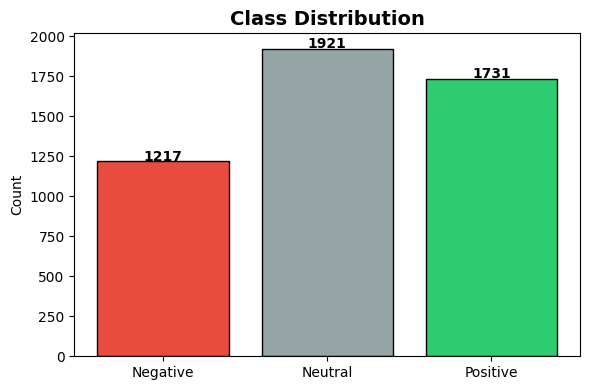

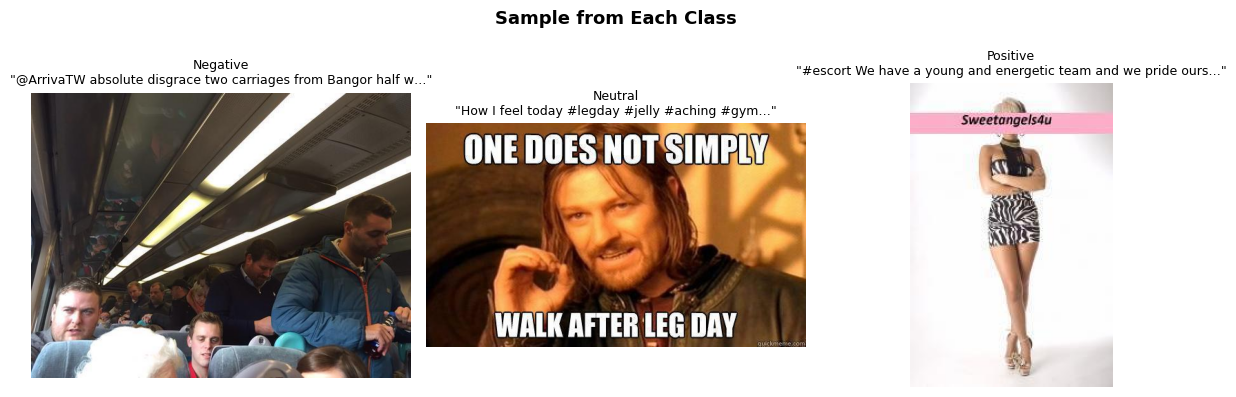

In [5]:
# ---- Class Distribution ONLY ----
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

counts = df['label'].value_counts().sort_index()

ax.bar([LABEL_NAMES[i] for i in counts.index], counts.values,
       color=['#e74c3c','#95a5a6','#2ecc71'], edgecolor='black')

ax.set_title('Class Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')

for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{CONFIG['OUTPUT_DIR']}/class_distribution.png",
            dpi=150, bbox_inches='tight')
plt.show()


# ---- Show 3 Sample Images (One per Class) ----
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for cls_idx, cls_name in enumerate(LABEL_NAMES):
    row = df[df['label'] == cls_idx].iloc[0]

    img = Image.open(row['img_path']).convert('RGB')

    with open(row['txt_path'], encoding='utf-8', errors='ignore') as f:
        txt = f.read().strip()[:60]

    axes[cls_idx].imshow(img)
    axes[cls_idx].set_title(f"{cls_name}\n\"{txt}…\"", fontsize=9)
    axes[cls_idx].axis('off')

plt.suptitle('Sample from Each Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Dataset & DataLoaders

In [6]:
# ─── Image transforms ─────────────────────────────────────────────────────
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD  = [0.229, 0.224, 0.225]

train_img_transform = transforms.Compose([
    transforms.Resize((CONFIG["IMAGE_SIZE"] + 32, CONFIG["IMAGE_SIZE"] + 32)),
    transforms.RandomCrop(CONFIG["IMAGE_SIZE"]),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMG_MEAN, IMG_STD),
])

val_img_transform = transforms.Compose([
    transforms.Resize((CONFIG["IMAGE_SIZE"], CONFIG["IMAGE_SIZE"])),
    transforms.ToTensor(),
    transforms.Normalize(IMG_MEAN, IMG_STD),
])

# ─── Tokenizer ────────────────────────────────────────────────────────────
tokenizer = BertTokenizer.from_pretrained(CONFIG["BERT_MODEL"])

# ─── Dataset ──────────────────────────────────────────────────────────────
class MVSADataset(Dataset):
    def __init__(self, dataframe, tokenizer, img_transform, max_len):
        self.df        = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = img_transform
        self.max_len   = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ── Text ──────────────────────────────────────────────────────────
        with open(row['txt_path'], encoding='utf-8', errors='ignore') as f:
            text = f.read().strip()
        # Clean
        text = re.sub(r'http\S+', '', text)
        text = re.sub(r'@\w+', '', text)
        text = re.sub(r'#(\w+)', r'\1', text)
        text = re.sub(r'[^\x00-\x7F]+', ' ', text).strip()
        if not text:
            text = "no text"

        enc = self.tokenizer(
            text,
            max_length   = self.max_len,
            padding      = 'max_length',
            truncation   = True,
            return_tensors = 'pt',
        )
        input_ids      = enc['input_ids'].squeeze(0)
        attention_mask = enc['attention_mask'].squeeze(0)

        # ── Image ─────────────────────────────────────────────────────────
        try:
            img = Image.open(row['img_path']).convert('RGB')
        except Exception:
            img = Image.new('RGB', (CONFIG["IMAGE_SIZE"], CONFIG["IMAGE_SIZE"]), (128, 128, 128))
        img = self.transform(img)

        label = torch.tensor(row['label'], dtype=torch.long)
        return input_ids, attention_mask, img, label


# ─── Train / Val / Test split ─────────────────────────────────────────────
train_df, test_df = train_test_split(
    df, test_size=CONFIG["TEST_SIZE"], stratify=df['label'], random_state=SEED)
train_df, val_df = train_test_split(
    train_df, test_size=CONFIG["VAL_SIZE"] / (1 - CONFIG["TEST_SIZE"]),
    stratify=train_df['label'], random_state=SEED)

print(f"Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")

train_ds = MVSADataset(train_df, tokenizer, train_img_transform, CONFIG["MAX_TEXT_LEN"])
val_ds   = MVSADataset(val_df,   tokenizer, val_img_transform,   CONFIG["MAX_TEXT_LEN"])
test_ds  = MVSADataset(test_df,  tokenizer, val_img_transform,   CONFIG["MAX_TEXT_LEN"])

train_loader = DataLoader(train_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG["BATCH_SIZE"], shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG["BATCH_SIZE"], shuffle=False,
                          num_workers=2, pin_memory=True)

print("DataLoaders ready ✓")

Train: 3407  |  Val: 731  |  Test: 731
DataLoaders ready ✓


## 6. Multimodal Model (BERT + ResNet-50 + Cross-Attention Fusion)

In [7]:
class TextEncoder(nn.Module):
    """BERT frozen except last 2 transformer layers."""
    def __init__(self, bert_model_name, hidden_dim):
        super().__init__()
        self.bert = BertModel.from_pretrained(bert_model_name)
        # Freeze embeddings + first 10 layers
        for param in self.bert.embeddings.parameters():
            param.requires_grad = False
        for layer in self.bert.encoder.layer[:10]:
            for param in layer.parameters():
                param.requires_grad = False
        bert_hidden = self.bert.config.hidden_size  # 768
        self.proj = nn.Sequential(
            nn.Linear(bert_hidden, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
        )

    def forward(self, input_ids, attention_mask):
        out  = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls  = out.last_hidden_state[:, 0, :]   # [B, 768]
        return self.proj(cls)                   # [B, hidden_dim]


class ImageEncoder(nn.Module):
    """ResNet-50 with fine-tuned layer3/4."""
    def __init__(self, hidden_dim):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        # Freeze stem + layer1/2
        for name, param in resnet.named_parameters():
            if not any(x in name for x in ['layer3', 'layer4', 'fc']):
                param.requires_grad = False
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])  # drop fc
        self.proj = nn.Sequential(
            nn.Linear(2048, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
        )

    def forward(self, x):
        feat = self.backbone(x).flatten(1)  # [B, 2048]
        return self.proj(feat)              # [B, hidden_dim]


class MultimodalFusion(nn.Module):
    """Gated cross-modal attention fusion."""
    def __init__(self, hidden_dim, dropout):
        super().__init__()
        self.attn = nn.MultiheadAttention(hidden_dim, num_heads=8,
                                           dropout=dropout, batch_first=True)
        self.gate  = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Sigmoid(),
        )
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)

    def forward(self, txt_feat, img_feat):
        # txt attends to img
        t = txt_feat.unsqueeze(1)  # [B, 1, H]
        i = img_feat.unsqueeze(1)  # [B, 1, H]
        cross, _ = self.attn(t, i, i)
        cross = self.norm1(cross.squeeze(1) + txt_feat)

        combined = torch.cat([cross, img_feat], dim=-1)
        g = self.gate(combined)
        fused = g * cross + (1 - g) * img_feat
        fused = self.norm2(fused)
        return fused


class MultimodalSentimentModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        H = cfg["HIDDEN_DIM"]
        D = cfg["DROPOUT"]

        self.text_enc   = TextEncoder(cfg["BERT_MODEL"], H)
        self.image_enc  = ImageEncoder(H)
        self.fusion     = MultimodalFusion(H, D)

        self.classifier = nn.Sequential(
            nn.Dropout(D),
            nn.Linear(H, H // 2),
            nn.GELU(),
            nn.Dropout(D / 2),
            nn.Linear(H // 2, cfg["NUM_CLASSES"]),
        )

    def forward(self, input_ids, attention_mask, images):
        txt_feat = self.text_enc(input_ids, attention_mask)
        img_feat = self.image_enc(images)
        fused    = self.fusion(txt_feat, img_feat)
        logits   = self.classifier(fused)
        return logits


model = MultimodalSentimentModel(CONFIG).to(DEVICE)
total  = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,} ({100*trainable/total:.1f}%)")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3794.16it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/uditanshu/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:14<00:00, 6.97MB/s]


Total params    : 136,144,707
Trainable params: 39,983,875 (29.4%)


## 7. Training Setup

In [8]:
# ─── Class weights for imbalanced data ────────────────────────────────────
class_counts = np.array([len(train_df[train_df['label'] == i]) for i in range(3)])
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float32).to(DEVICE)
class_weights = class_weights / class_weights.sum() * 3   # normalise

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# ─── Differential learning rates ──────────────────────────────────────────
optimizer = torch.optim.AdamW([
    {'params': model.text_enc.bert.encoder.layer[10:].parameters(), 'lr': CONFIG["LR"] * 0.5},
    {'params': model.text_enc.proj.parameters(),                    'lr': CONFIG["LR"]},
    {'params': model.image_enc.parameters(),                        'lr': CONFIG["LR"]},
    {'params': model.fusion.parameters(),                           'lr': CONFIG["LR"]},
    {'params': model.classifier.parameters(),                       'lr': CONFIG["LR"] * 2},
], weight_decay=CONFIG["WEIGHT_DECAY"])

# ─── LR scheduler: warmup + cosine decay ──────────────────────────────────
total_steps   = CONFIG["NUM_EPOCHS"] * len(train_loader)
warmup_steps  = 2 * len(train_loader)

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(0.05, 0.5 * (1.0 + np.cos(np.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

print("Optimizer & scheduler ready ✓")
print(f"Class weights: {class_weights.cpu().numpy().round(3)}")

Optimizer & scheduler ready ✓
Class weights: [1.285 0.813 0.903]


## 8. Training Loop

In [11]:
def run_epoch(loader, is_train=True):
    model.train(is_train)
    total_loss, all_preds, all_labels = 0.0, [], []

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for input_ids, attention_mask, images, labels in tqdm(loader, leave=False):
            input_ids      = input_ids.to(DEVICE)
            attention_mask = attention_mask.to(DEVICE)
            images         = images.to(DEVICE)
            labels         = labels.to(DEVICE)

            with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
                logits = model(input_ids, attention_mask, images)
                loss   = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), CONFIG["GRAD_CLIP"])
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()

            total_loss += loss.item()
            preds = logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, acc, f1


# ─── Training loop ────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [],
           'train_acc':  [], 'val_acc':  [],
           'train_f1':   [], 'val_f1':   []}

best_val_f1  = 0.0
patience_ctr = 0
best_ckpt    = f"{CONFIG['OUTPUT_DIR']}/best_model.pt"

print(f"Starting training for up to {CONFIG['NUM_EPOCHS']} epochs…\n")
print(f"{'Epoch':>5} | {'TrLoss':>7} | {'TrAcc':>6} | {'TrF1':>6} | "
      f"{'VaLoss':>7} | {'VaAcc':>6} | {'VaF1':>6} | {'LR':>9}")
print('-' * 72)

for epoch in range(1, CONFIG["NUM_EPOCHS"] + 1):
    tr_loss, tr_acc, tr_f1 = run_epoch(train_loader, is_train=True)
    va_loss, va_acc, va_f1 = run_epoch(val_loader,   is_train=False)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)
    history['train_f1'].append(tr_f1)
    history['val_f1'].append(va_f1)

    current_lr = scheduler.get_last_lr()[0]
    flag = ''

    if va_f1 > best_val_f1:
        best_val_f1  = va_f1
        patience_ctr = 0
        torch.save({
            'epoch':       epoch,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'val_f1':      va_f1,
            'val_acc':     va_acc,
            'config':      CONFIG,
        }, best_ckpt)
        flag = '  ← best'
    else:
        patience_ctr += 1

    print(f"{epoch:5d} | {tr_loss:7.4f} | {tr_acc:6.4f} | {tr_f1:6.4f} | "
          f"{va_loss:7.4f} | {va_acc:6.4f} | {va_f1:6.4f} | {current_lr:9.2e}{flag}")

    if patience_ctr >= CONFIG["PATIENCE"]:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nBest Val F1: {best_val_f1:.4f}  →  saved to {best_ckpt}")

Starting training for up to 20 epochs…

Epoch |  TrLoss |  TrAcc |   TrF1 |  VaLoss |  VaAcc |   VaF1 |        LR
------------------------------------------------------------------------


    1 |  1.1167 | 0.3422 | 0.3459 |  1.0680 | 0.4487 | 0.4517 |  5.00e-06  ← best


    2 |  1.0041 | 0.5333 | 0.5362 |  0.9055 | 0.6211 | 0.6214 |  1.00e-05  ← best


    3 |  0.8439 | 0.6625 | 0.6638 |  0.8433 | 0.6457 | 0.6441 |  9.92e-06  ← best


    4 |  0.7600 | 0.7156 | 0.7164 |  0.8092 | 0.6867 | 0.6851 |  9.70e-06  ← best


...

    7 |  0.5773 | 0.8474 | 0.8476 |  0.8591 | 0.7004 | 0.7006 |  8.21e-06  ← best


    8 |  0.5168 | 0.8870 | 0.8870 |  0.8893 | 0.6826 | 0.6839 |  7.50e-06


    9 |  0.4708 | 0.9210 | 0.9211 |  0.9291 | 0.6840 | 0.6864 |  6.71e-06


   10 |  0.4423 | 0.9331 | 0.9331 |  0.9432 | 0.6867 | 0.6888 |  5.87e-06


   11 |  0.4243 | 0.9486 | 0.9486 |  0.9575 | 0.6881 | 0.6888 |  5.00e-06

Early stopping at epoch 11.

Best Val F1: 0.7006  →  saved to ./outputs/best_model.pt


## 9. Training Curves

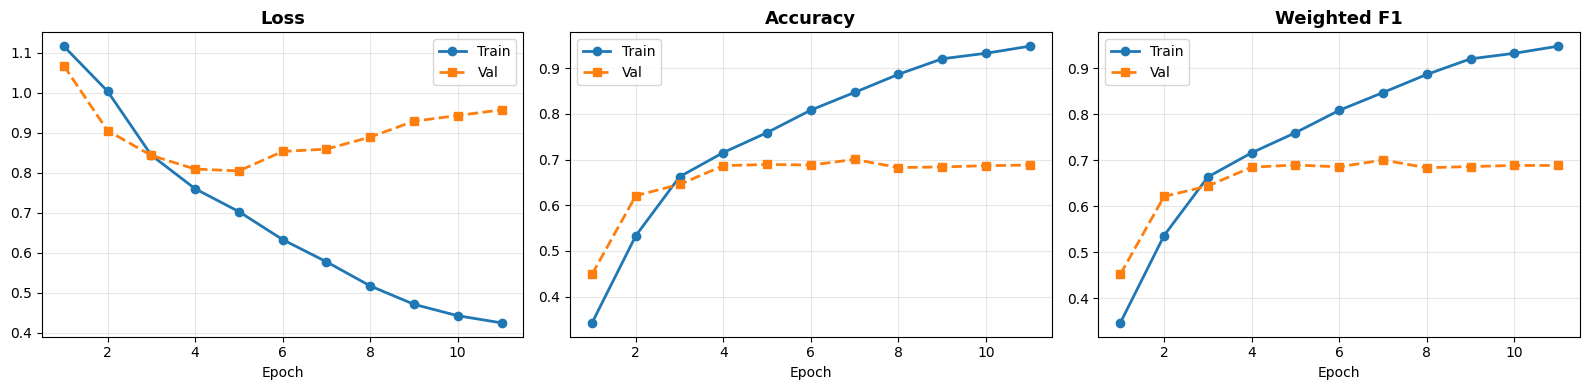

In [12]:
epochs_ran = range(1, len(history['train_loss']) + 1)
fig, axes  = plt.subplots(1, 3, figsize=(16, 4))

for ax, key, title in zip(
    axes,
    [('train_loss','val_loss'), ('train_acc','val_acc'), ('train_f1','val_f1')],
    ['Loss', 'Accuracy', 'Weighted F1'],
):
    ax.plot(epochs_ran, history[key[0]], 'o-', label='Train', linewidth=2)
    ax.plot(epochs_ran, history[key[1]], 's--', label='Val',   linewidth=2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CONFIG['OUTPUT_DIR']}/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

## 10. Test Evaluation

In [13]:
# ─── Load best checkpoint ─────────────────────────────────────────────────
ckpt = torch.load(best_ckpt, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f"Loaded best model from epoch {ckpt['epoch']}  (val F1 = {ckpt['val_f1']:.4f})")

# ─── Predict ──────────────────────────────────────────────────────────────
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for input_ids, attention_mask, images, labels in tqdm(test_loader):
        input_ids      = input_ids.to(DEVICE)
        attention_mask = attention_mask.to(DEVICE)
        images         = images.to(DEVICE)

        logits = model(input_ids, attention_mask, images)
        probs  = F.softmax(logits, dim=-1).cpu().numpy()
        preds  = logits.argmax(dim=-1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)

# ─── Metrics ──────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print(" TEST SET RESULTS")
print("=" * 55)
print(f" Accuracy : {accuracy_score(all_labels, all_preds):.4f}")
print(f" Weighted F1: {f1_score(all_labels, all_preds, average='weighted'):.4f}")
print(f" Macro F1   : {f1_score(all_labels, all_preds, average='macro'):.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=LABEL_NAMES))

Loaded best model from epoch 7  (val F1 = 0.7006)


100%|██████████| 46/46 [00:05<00:00,  9.19it/s]


 TEST SET RESULTS
 Accuracy : 0.6963
 Weighted F1: 0.6968
 Macro F1   : 0.6910

              precision    recall  f1-score   support

    Negative       0.61      0.66      0.64       183
     Neutral       0.71      0.67      0.69       288
    Positive       0.75      0.75      0.75       260

    accuracy                           0.70       731
   macro avg       0.69      0.69      0.69       731
weighted avg       0.70      0.70      0.70       731



## 11. Confusion Matrix

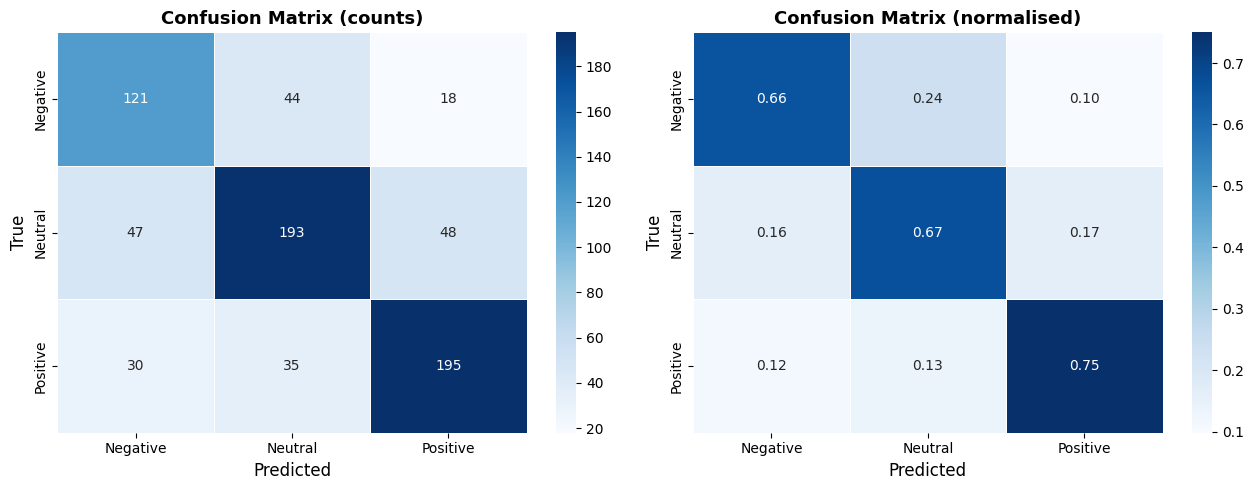

In [14]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Confusion Matrix (counts)', 'Confusion Matrix (normalised)'],
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
                linewidths=0.5, ax=ax)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('True', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{CONFIG['OUTPUT_DIR']}/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

## 12. Save Full Deployment Package

In [15]:
import shutil

deploy_dir = Path(CONFIG["OUTPUT_DIR"]) / "deployment"
deploy_dir.mkdir(exist_ok=True)

# ── 1. Best model weights ──────────────────────────────────────────────────
shutil.copy(best_ckpt, deploy_dir / "best_model.pt")

# ── 2. Config + label map ──────────────────────────────────────────────────
deploy_meta = {
    "config"     : CONFIG,
    "label_map"  : LABEL_MAP,
    "label_names": LABEL_NAMES,
    "img_mean"   : IMG_MEAN,
    "img_std"    : IMG_STD,
    "test_acc"   : float(accuracy_score(all_labels, all_preds)),
    "test_f1"    : float(f1_score(all_labels, all_preds, average='weighted')),
}
with open(deploy_dir / "model_meta.json", 'w') as f:
    json.dump(deploy_meta, f, indent=2)

# ── 3. Inference helper (copy-paste ready for webapp) ─────────────────────
inference_code = '''
# inference.py  ——  drop this next to best_model.pt for your webapp
import re, json, torch, torch.nn.functional as F
from pathlib import Path
from PIL import Image
from torchvision import transforms
from transformers import BertTokenizer
# Import your model class here:
# from model import MultimodalSentimentModel

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
META    = json.load(open("deployment/model_meta.json"))
CONFIG  = META["config"]

tokenizer = BertTokenizer.from_pretrained(CONFIG["BERT_MODEL"])

img_transform = transforms.Compose([
    transforms.Resize((CONFIG["IMAGE_SIZE"], CONFIG["IMAGE_SIZE"])),
    transforms.ToTensor(),
    transforms.Normalize(META["img_mean"], META["img_std"]),
])

def load_model():
    model = MultimodalSentimentModel(CONFIG).to(DEVICE)
    ckpt  = torch.load("deployment/best_model.pt", map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    return model

def predict(model, text: str, image_path: str) -> dict:
    text = re.sub(r"http\\S+", "", text)
    text = re.sub(r"@\\w+", "", text)
    text = re.sub(r"#(\\w+)", r"\\1", text).strip() or "no text"

    enc = tokenizer(text, max_length=CONFIG["MAX_TEXT_LEN"],
                    padding="max_length", truncation=True, return_tensors="pt")
    input_ids      = enc["input_ids"].to(DEVICE)
    attention_mask = enc["attention_mask"].to(DEVICE)

    img = img_transform(Image.open(image_path).convert("RGB")).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(input_ids, attention_mask, img)
        probs  = F.softmax(logits, dim=-1).cpu().numpy()[0]

    pred_idx = probs.argmax()
    return {
        "label"       : META["label_names"][pred_idx],
        "confidence"  : float(probs[pred_idx]),
        "probabilities": {n: float(p) for n, p in zip(META["label_names"], probs)},
    }
'''

with open(deploy_dir / "inference.py", 'w') as f:
    f.write(inference_code)

print("Deployment package saved:")
for p in sorted(deploy_dir.rglob('*')):
    print(f"  {p.relative_to(CONFIG['OUTPUT_DIR'])}")

Deployment package saved:
  deployment/best_model.pt
  deployment/inference.py
  deployment/model_meta.json


## 13. Quick Sanity Inference Demo

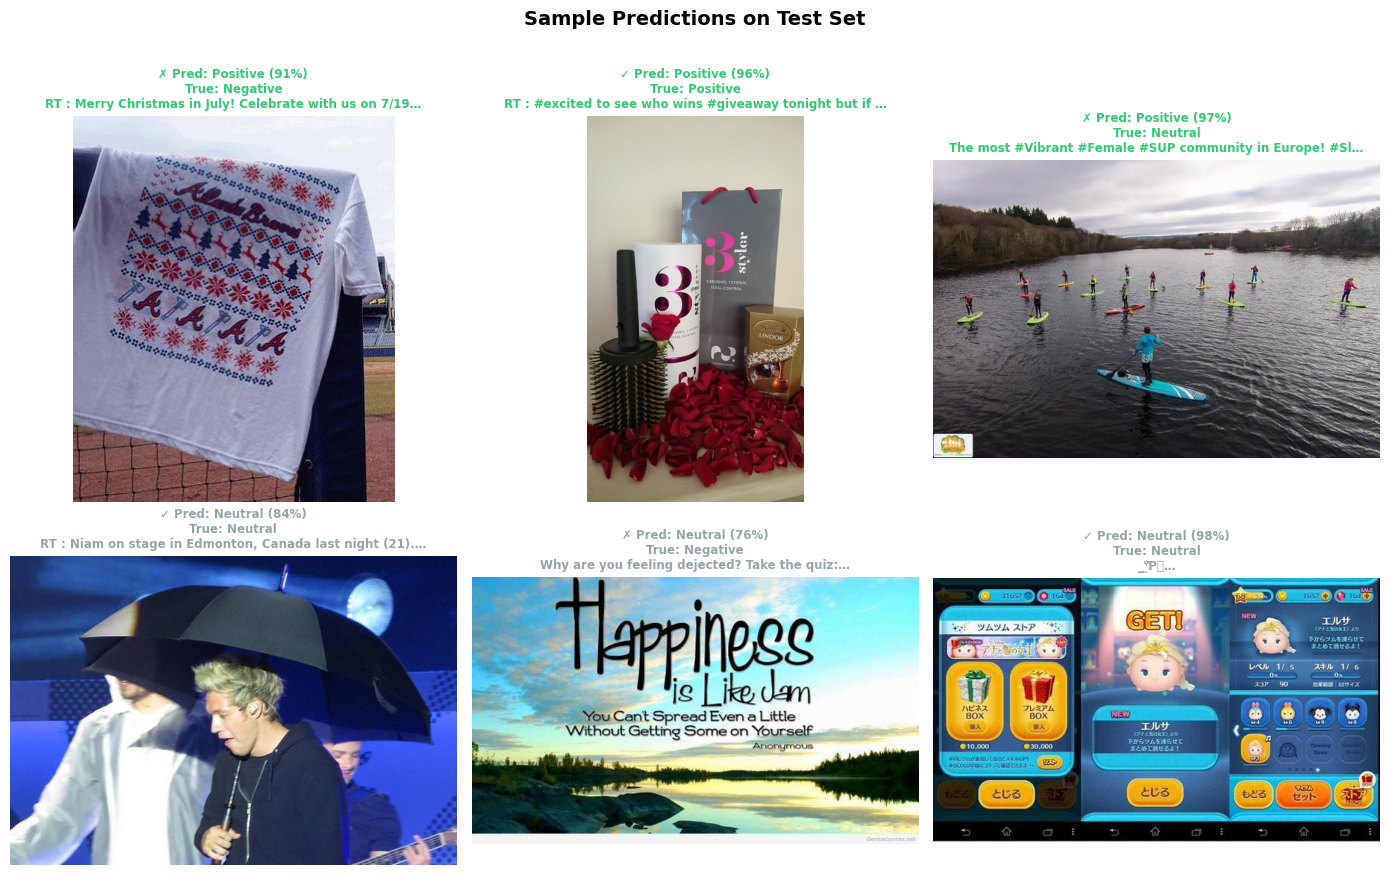


All done! 🎉
Best model  → ./outputs/best_model.pt
Deployment  → outputs/deployment


In [16]:
# Pick 6 random samples from the test set and show predictions vs ground truth
indices = random.sample(range(len(test_df)), min(6, len(test_df)))
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

model.eval()
id2name = {v: k for k, v in LABEL_MAP.items()}
COLORS  = {'positive': '#2ecc71', 'neutral': '#95a5a6', 'negative': '#e74c3c'}

for ax_idx, sample_idx in enumerate(indices):
    row = test_df.iloc[sample_idx]
    img_pil = Image.open(row['img_path']).convert('RGB')

    with open(row['txt_path'], encoding='utf-8', errors='ignore') as f:
        text = f.read().strip()
    text_clean = re.sub(r'http\S+|@\w+', '', text).strip() or 'no text'

    enc = tokenizer(text_clean, max_length=CONFIG["MAX_TEXT_LEN"],
                    padding='max_length', truncation=True, return_tensors='pt')
    with torch.no_grad():
        logits = model(
            enc['input_ids'].to(DEVICE),
            enc['attention_mask'].to(DEVICE),
            val_img_transform(img_pil).unsqueeze(0).to(DEVICE),
        )
        probs = F.softmax(logits, dim=-1).cpu().numpy()[0]

    pred   = id2name[probs.argmax()]
    truth  = id2name[row['label']]
    conf   = probs.max()
    ok     = '✓' if pred == truth else '✗'

    axes[ax_idx].imshow(img_pil)
    axes[ax_idx].axis('off')
    title = (
        f"{ok} Pred: {pred.capitalize()} ({conf:.0%})\n"
        f"True: {truth.capitalize()}\n"
        f"{text_clean[:55]}…"
    )
    color = COLORS.get(pred, 'black')
    axes[ax_idx].set_title(title, fontsize=8.5, color=color, fontweight='bold')

plt.suptitle('Sample Predictions on Test Set', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{CONFIG['OUTPUT_DIR']}/sample_predictions.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nAll done! 🎉")
print(f"Best model  → {best_ckpt}")
print(f"Deployment  → {deploy_dir}")